In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable
from boulder_statistics.analysis.quick_calculate import FittingFunction
from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [2]:
manual_db = pl.read_parquet(r".database\manual_detection_database.parquet")
auto_db = dp.combined_mask_no_merge.filter(pl.col("face") == "posx").collect()

manual_db

i,j,manual_detect_boulder_id,face
i32,i32,u32,str
7661,5626,7883757,"""posx"""
7661,5627,7883757,"""posx"""
7661,5628,7883757,"""posx"""
7661,5629,7883757,"""posx"""
7661,5630,7883757,"""posx"""
…,…,…,…
40,2454,10549449,"""posx"""
40,2455,10549449,"""posx"""
40,2456,10549449,"""posx"""


In [3]:
auto_db_agg = auto_db.group_by("row_id").agg(pl.len().alias("auto_boulder_size"))
manual_db_agg = manual_db.group_by("manual_detect_boulder_id").agg(pl.len().alias("manual_boulder_size"))

db_intersections = manual_db.join(
    auto_db,
    on=["i", "j"],
    how="inner",
).select("i", "j", "lod_level", "lod_code", "row_id", "manual_detect_boulder_id")

manual_db_agg

manual_detect_boulder_id,manual_boulder_size
u32,u32
16200577,31
5013688,111
1411612,58
10858411,20088
11518133,15299
…,…
14522995,58826
14377489,153423
566518,68617


In [5]:
db_intersections_agg = db_intersections.group_by("manual_detect_boulder_id", "row_id").agg(
    pl.len().alias("overlap"),
    pl.col("lod_level").first(),
    pl.col("lod_code").first()
)

db_jaccard = db_intersections_agg.join(
    auto_db_agg,
    on="row_id",
    how="left",
).join(
    manual_db_agg,
    on="manual_detect_boulder_id",
    how="left",
).with_columns(
    (
        pl.col("overlap") / (pl.col("auto_boulder_size") + pl.col("manual_boulder_size") - pl.col("overlap"))
    ).alias("Jaccard_index")
)

db_jaccard

manual_detect_boulder_id,row_id,overlap,lod_level,lod_code,auto_boulder_size,manual_boulder_size,Jaccard_index
u32,u32,u32,u8,str,u32,u32,f64
4180251,2907293,2286,1,"""D""",2624,2586,0.781806
832312,1924120,6049,1,"""C""",10304,10011,0.424015
7324622,377826,62,4,"""ABCA""",62,54999,0.001127
7324622,377830,39,4,"""ABCA""",39,54999,0.000709
7324622,377879,33,4,"""ABCA""",33,54999,0.0006
…,…,…,…,…,…,…,…
4455779,927932,69,4,"""ADDA""",388,65834,0.001043
629096,975913,436,1,"""B""",2432,41339,0.010061
8293826,976095,3,1,"""B""",3264,264,0.000851


In [6]:
db_jaccard_agg = (
    db_jaccard
    .group_by(["lod_level", "manual_detect_boulder_id"])
    .agg(
        pl.all().get(
            pl.col("Jaccard_index").arg_max()
        )
    )
).with_columns(
    (pl.col("manual_boulder_size") // (2 ** (8 - 2 * pl.col("lod_level")))).alias("viewport_size"),
    (pl.col("auto_boulder_size") / pl.col("manual_boulder_size")).alias("area_diff_factor")
)

db_jaccard_agg

lod_level,manual_detect_boulder_id,row_id,overlap,lod_code,auto_boulder_size,manual_boulder_size,Jaccard_index,viewport_size,area_diff_factor
u8,u32,u32,u32,str,u32,u32,f64,u32,f64
3,11649605,2076660,7412,"""CAC""",10444,11647,0.504939,2911,0.896712
1,11226799,2907325,28668,"""D""",28800,34352,0.831342,536,0.838379
4,14438232,397748,440,"""ABCC""",440,12735,0.03455,12735,0.03455
4,15610813,443630,782,"""ABDB""",981,25652,0.03025,25652,0.038243
4,8173526,510346,2478,"""ACAA""",2478,19182,0.129184,19182,0.129184
…,…,…,…,…,…,…,…,…,…
4,798910,3239867,152,"""DBAD""",152,33284,0.004567,33284,0.004567
3,14522995,739471,304,"""ADA""",304,58826,0.005168,14706,0.005168
4,9611116,1775662,1004,"""BDBA""",1004,12247,0.081979,12247,0.081979


C:\Users\Joshu\AppData\Local\Temp\ipykernel_25148\1058435683.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


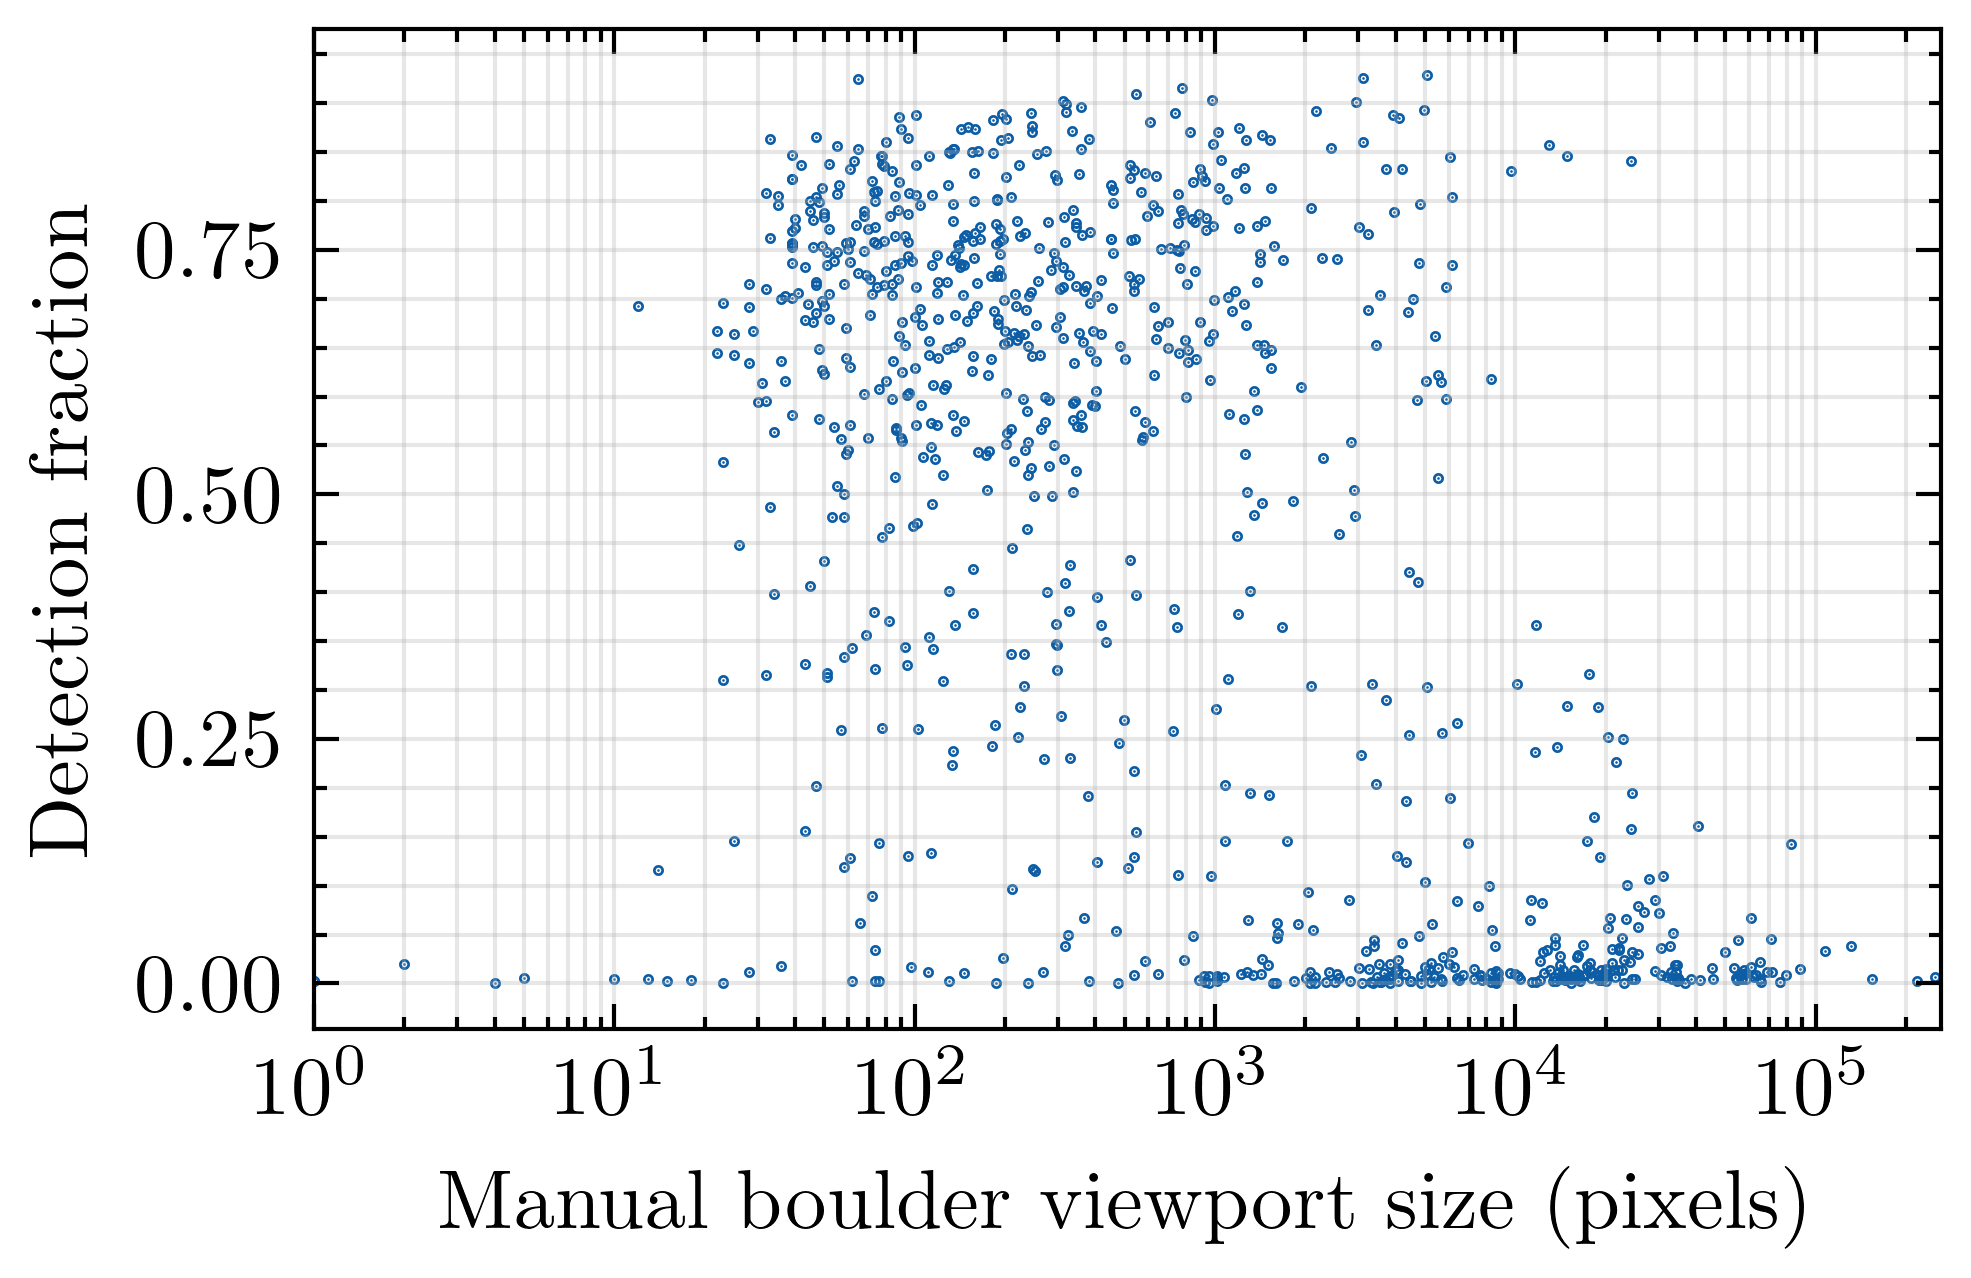

In [7]:
x = db_jaccard_agg["viewport_size"].to_numpy()
j = db_jaccard_agg["Jaccard_index"].to_numpy()

plt.scatter(x, j, s = 0.1)
plt.xscale("log")
# plt.ylim(0, 1.05)
plt.xlim(1, 512*512)
plt.xlabel("Manual boulder viewport size (pixels)")
plt.ylabel("Detection fraction")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

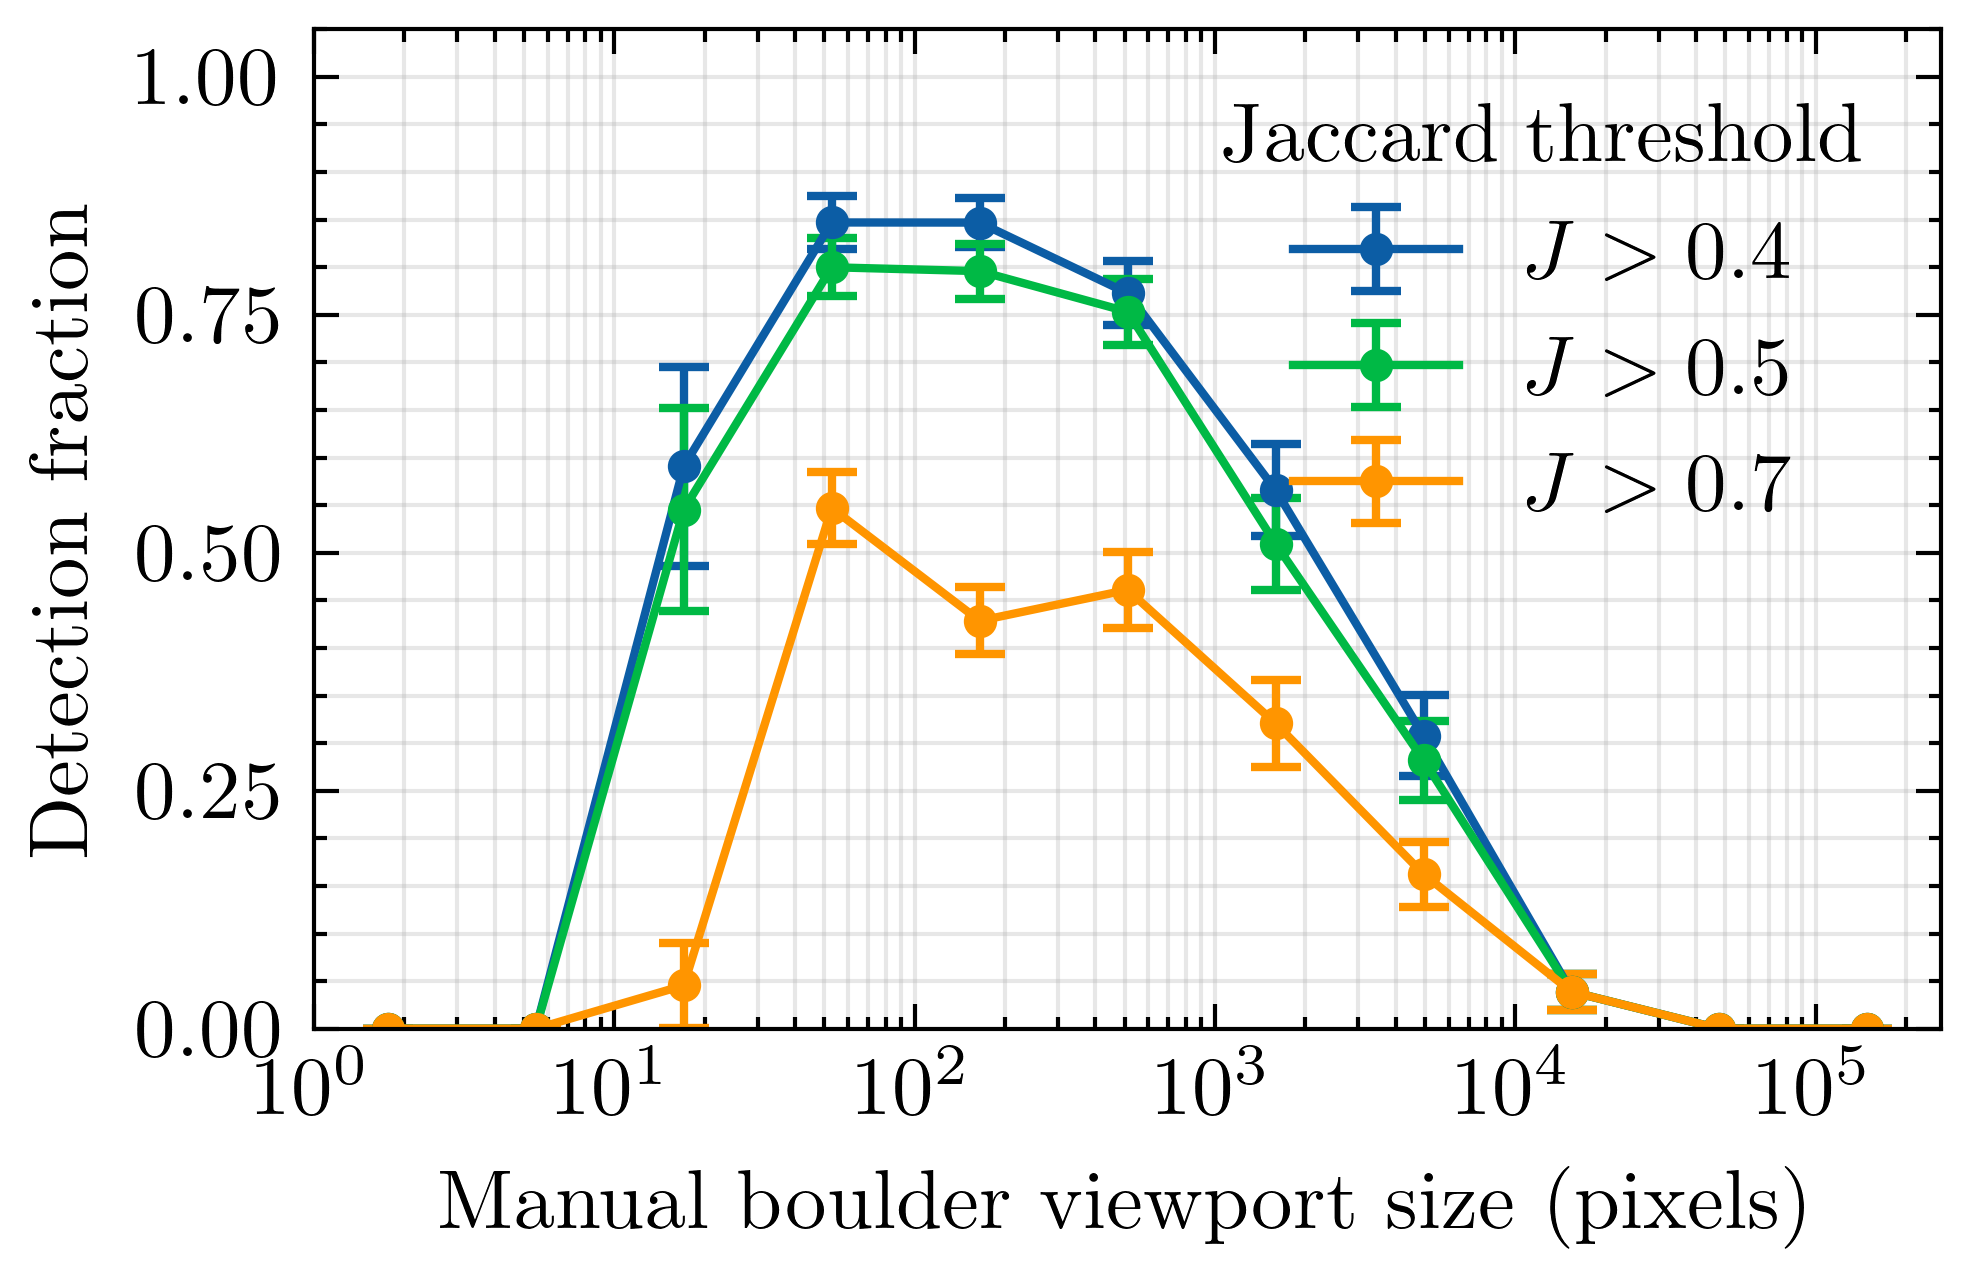

In [8]:
bins = np.geomspace(1, 512 * 512, 12)

centres = np.sqrt(bins[:-1] * bins[1:])

total, _ = np.histogram(x, bins=bins)

thresholds = [0.4, 0.5, 0.7]

# plt.figure(figsize=(8, 5))

for thresh in thresholds:
    success, _ = np.histogram(x[j > thresh], bins=bins)

    rate = np.divide(
        success,
        total,
        out=np.full_like(success, np.nan, dtype=float),
        where=total > 0,
    )

    err = np.sqrt(rate * (1 - rate) / total)
    err[total == 0] = np.nan

    plt.errorbar(
        centres,
        rate,
        yerr=err,
        marker=".",
        capsize=3,
        label=f"$J > {thresh}$",
    )

plt.xscale("log")
plt.ylim(0, 1.05)
plt.xlim(1, 512*512)
plt.xlabel("Manual boulder viewport size (pixels)")
plt.ylabel("Detection fraction")
plt.grid(True, which="both", alpha=0.3)
plt.legend(title="Jaccard threshold")
plt.savefig(".plots/S_from_manual_detection.png")
plt.show()


C:\Users\Joshu\AppData\Local\Temp\ipykernel_25148\54756469.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


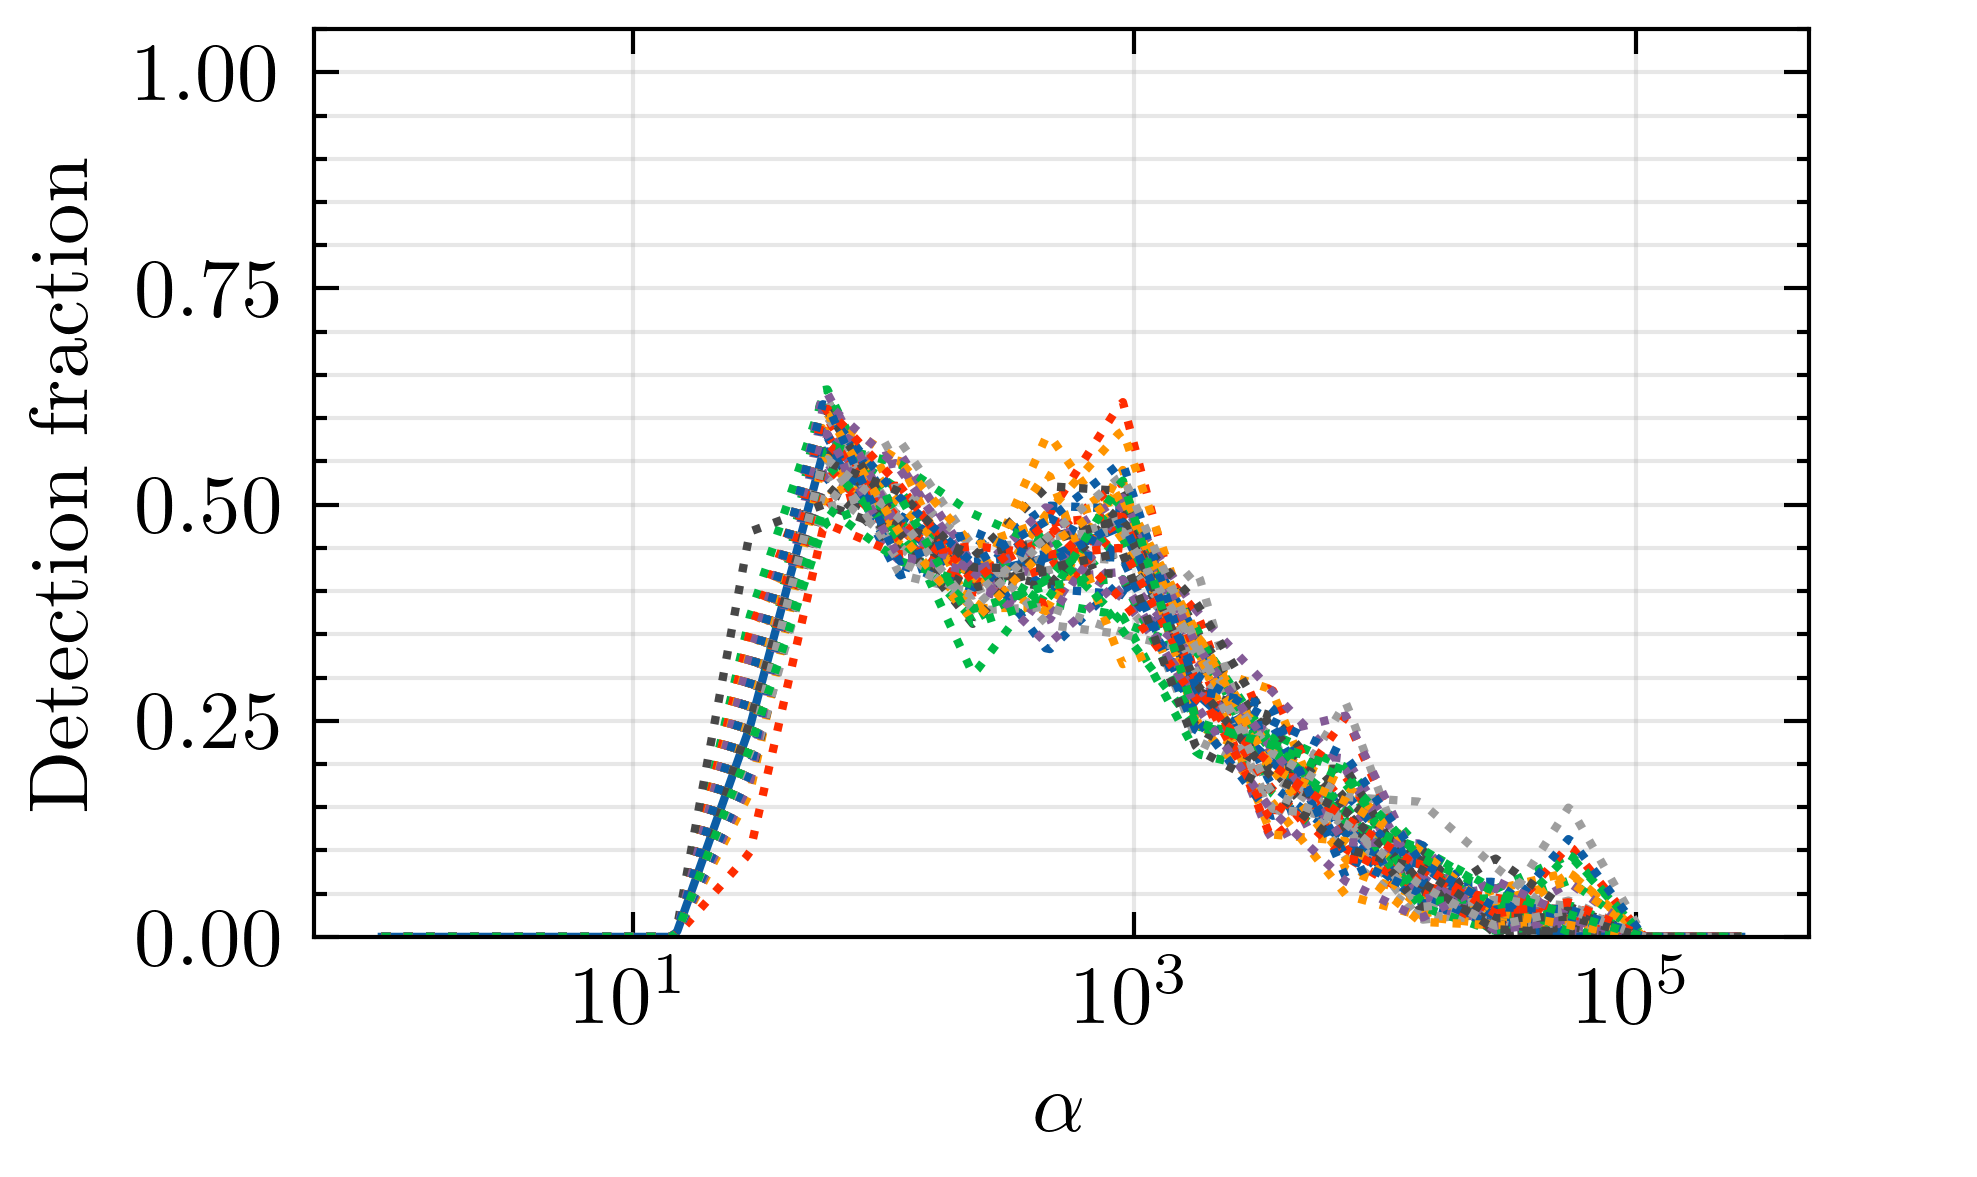

In [9]:
from boulder_statistics.analysis.sensitivity_model import SensitivityModel
x_smooth = np.geomspace(1, 512 ** 2, 300)


sm = SensitivityModel(
        df = db_jaccard_agg,
        number_of_bins=16
    )

total_s = sm.best_p_function(x_smooth)

plt.plot(
    x_smooth,
    total_s,
    # label=r"$S(\alpha)$"
)

for i in range(50):
    rng = np.random.default_rng(i)
    plt.plot(
        x_smooth,
        sm.random_p_function(rng)(x_smooth),
        # label=r"$S(\alpha)$",
        ls = ":"
    )

plt.xscale("log")
# plt.xlim(1, 512*512)
plt.ylim(0, 1.05)
plt.xlabel(r"$\alpha$")
plt.ylabel("Detection fraction")
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
plt.tight_layout()
plt.grid(True, which="both", alpha=0.3)
# plt.savefig(".plots/S_alpha_vs_S_alpha_omega.png")
plt.show()

C:\Users\Joshu\AppData\Local\Temp\ipykernel_25148\2227940164.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


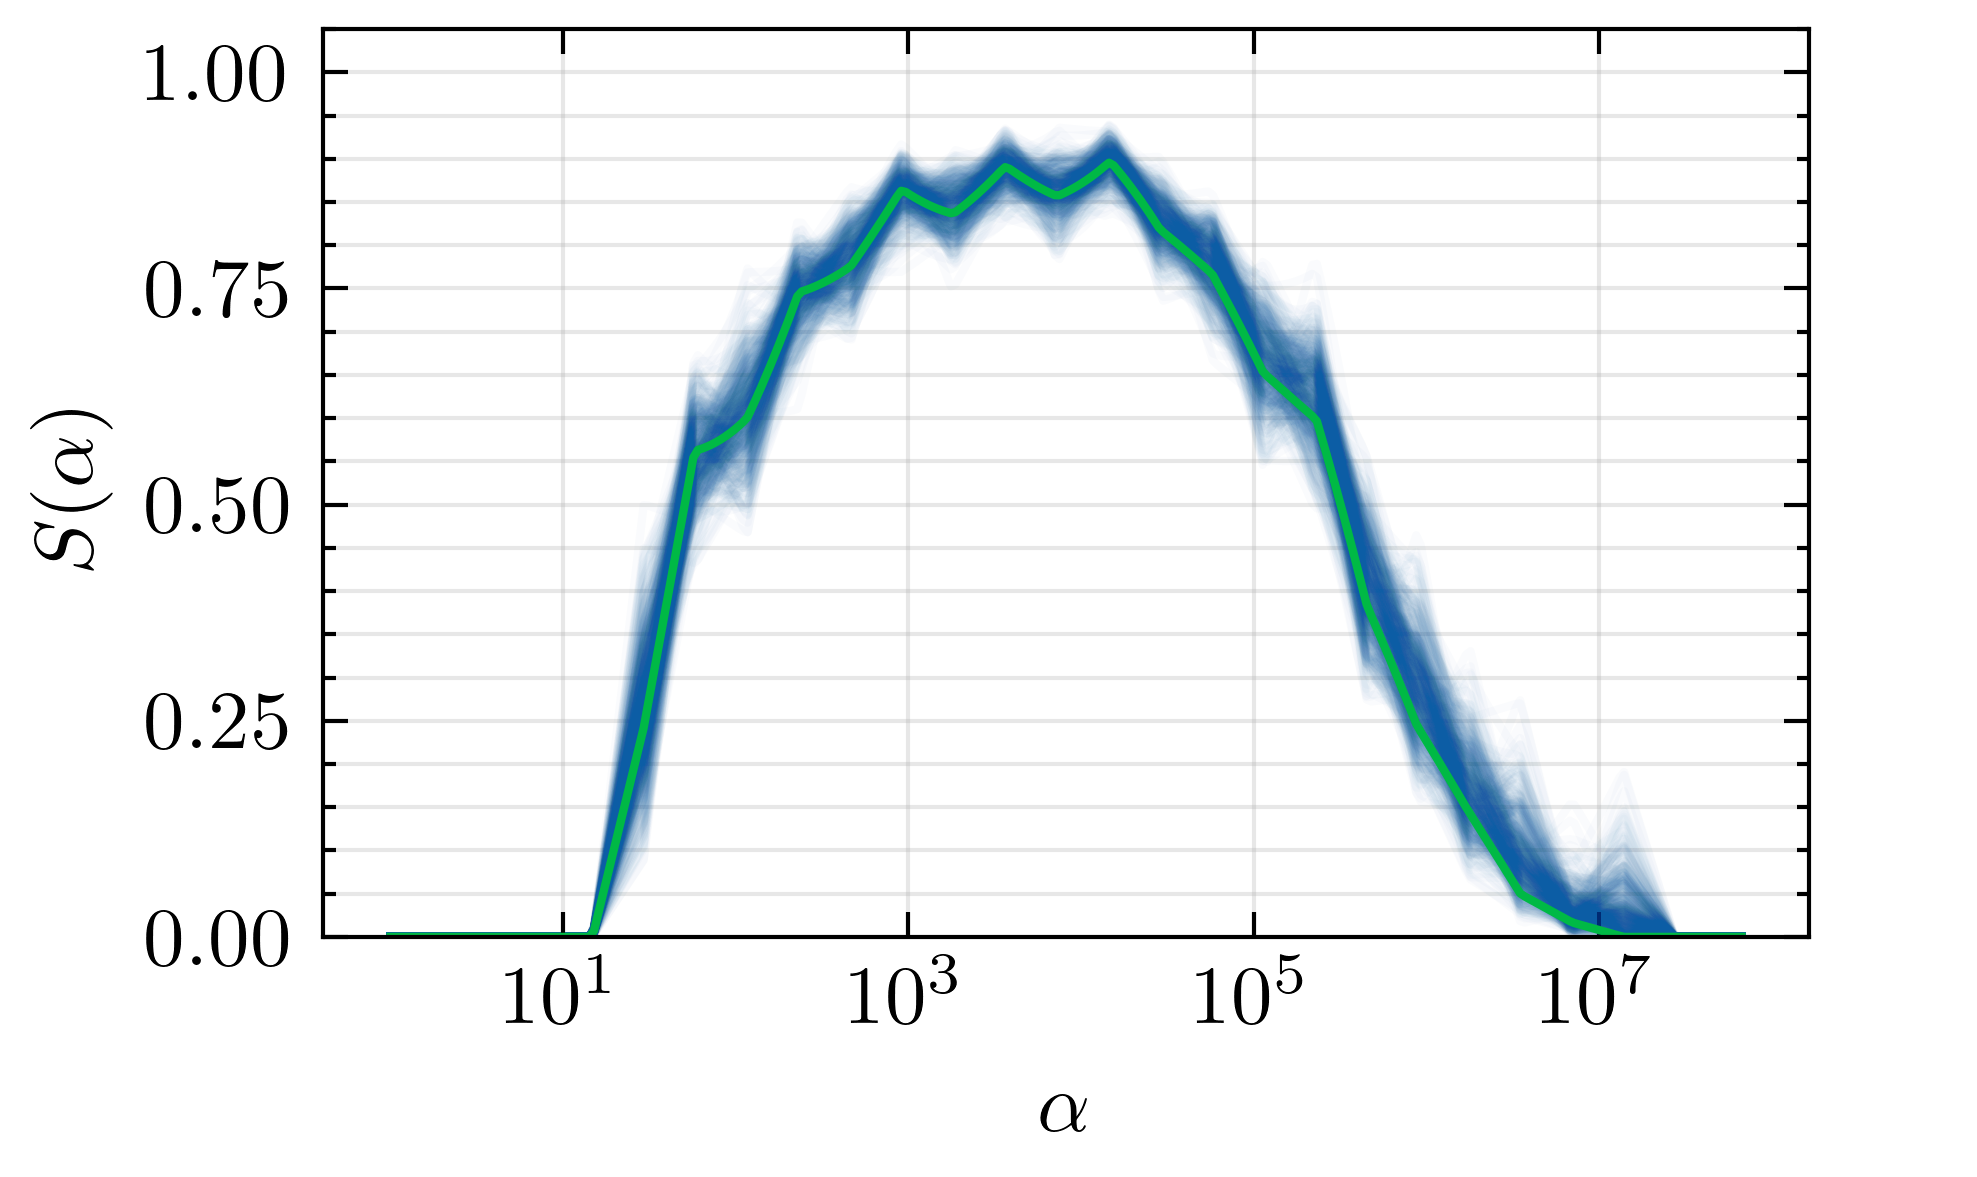

In [21]:
from boulder_statistics.analysis.sensitivity_model import SensitivityModel

x_smooth = np.geomspace(1, ((512 ** 2) * 2 ** (2 * 4)), 300)

for i in range(500):
    sm = SensitivityModel(
        df = db_jaccard_agg,
        number_of_bins=16
    )

    # y_smooth = sm.best_p_function(x_smooth)
    # plt.plot(x_smooth, y_smooth, label=r"$S(\alpha|\omega_0)$", linestyle=":")
    # plt.scatter(centres, rate, color="C0", zorder=3, label="Bin centres")

    rng = np.random.default_rng(i)

    total_s = 1 - np.prod([
                1 - sm.random_p_function(rng)(x_smooth / (2 ** (2 * 4 - 2 * i))) for i in range(5)
            ], axis=0)

    plt.plot(
        x_smooth,
        total_s,
        color='C0', alpha=0.02
        # label=r"$S(\alpha)$"
    )

total_s = 1 - np.prod([
            1 - sm.best_p_function(x_smooth / (2 ** (2 * 4 - 2 * i))) for i in range(5)
        ], axis=0)

plt.plot(
    x_smooth,
    total_s,
    color='C1'
    # label=r"$S(\alpha)$"
)

plt.xscale("log")
# plt.xlim(1, 512*512)
plt.ylim(0, 1.05)
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$S(\alpha)$")
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
plt.tight_layout()
plt.grid(True, which="both", alpha=0.3)
plt.savefig(".plots/S_alpha.png")
plt.show()

In [11]:
db_jaccard_agg.write_parquet(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products\db_jaccard_agg.parquet")

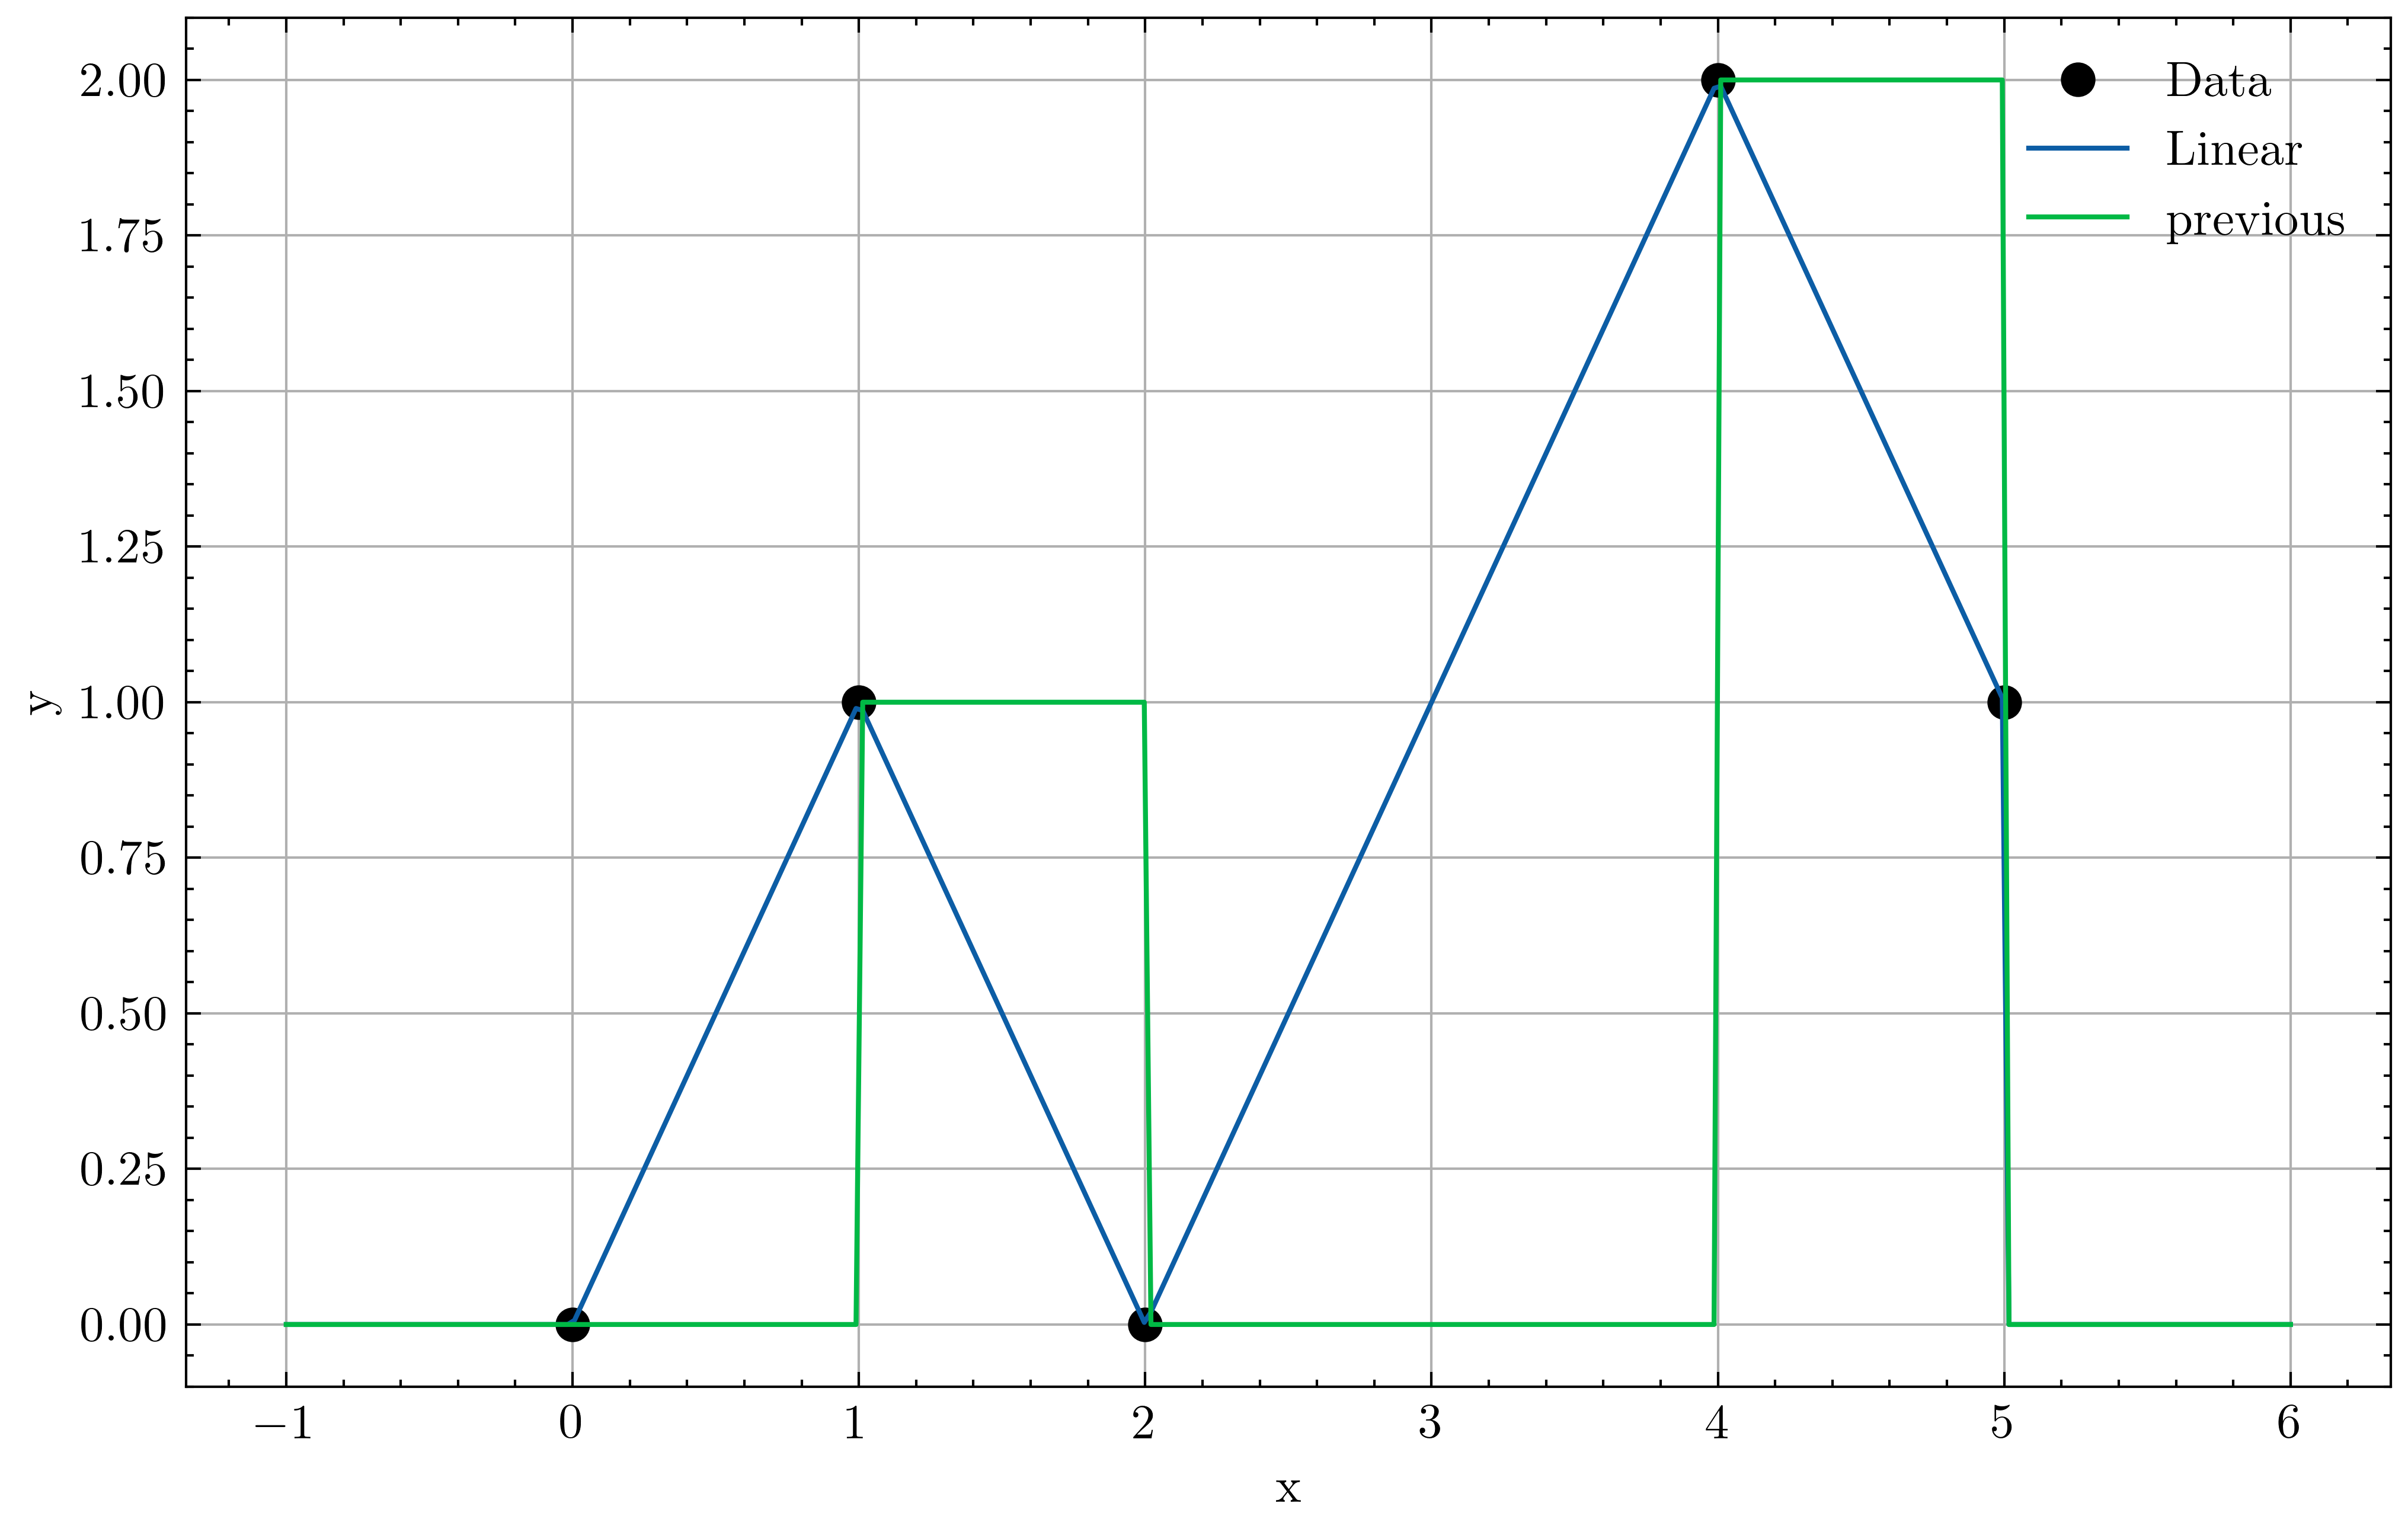

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Original data
x = np.array([0, 1, 2, 4, 5])
y = np.array([0, 1, 0, 2, 1])

# Points where we want interpolated values
x_new = np.linspace(-1, 6, 300)

# Create interpolators
f_linear = interp1d(x, y, kind="linear", fill_value=0, bounds_error=False)
f_nearest = interp1d(x, y, kind="nearest", fill_value=0, bounds_error=False)
f_cubic = interp1d(x, y, kind="previous", fill_value=0, bounds_error=False)

# Evaluate
y_linear = f_linear(x_new)
y_nearest = f_nearest(x_new)
y_cubic = f_cubic(x_new)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, y, "ko", label="Data")
plt.plot(x_new, y_linear, label="Linear")
# plt.plot(x_new, y_nearest, label="Nearest")
plt.plot(x_new, y_cubic, label="previous")

plt.legend()
plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.show()